web-edu.mtx nodes: 3031 edges: 6474
web-EPA.edges nodes: 4271 edges: 8909
web-polblogs.mtx nodes: 643 edges: 2280


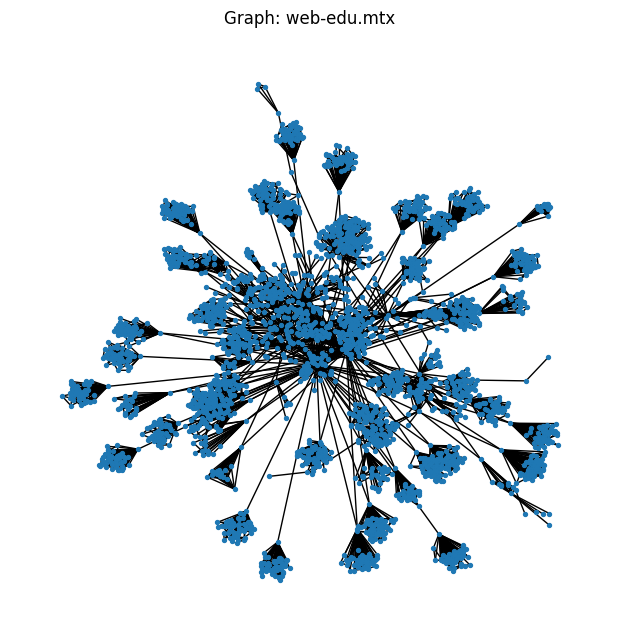

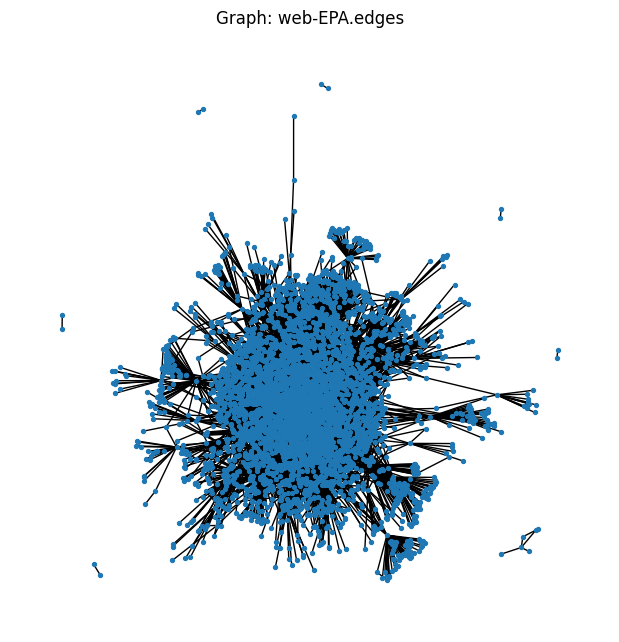

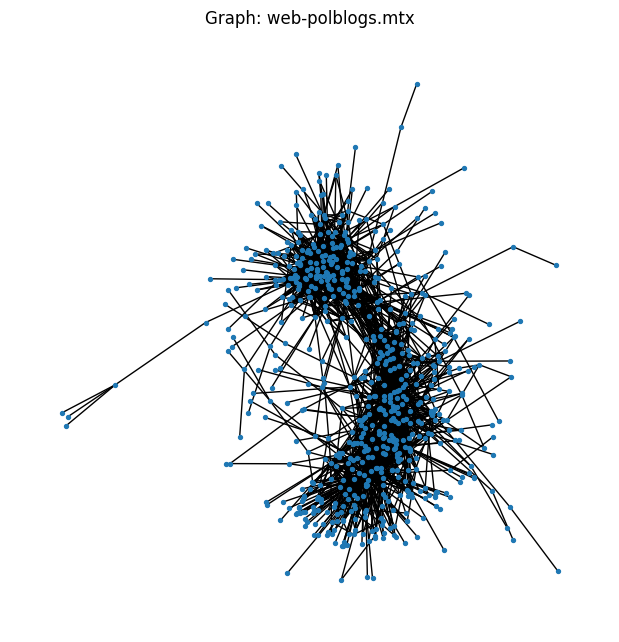


================ GRAPH: web-edu.mtx ================

---- Random Fire Start ----

Method       Protected      Burned Nodes      Saved Nodes      Saved Fraction
--------------------------------------------------------------------------
DEG        454            33.47            2543.53          0.839     
BC         454            39.53            2537.47          0.837     
CI         454            41.70            2535.30          0.836     
RWR        454            39.03            2537.97          0.837     
QW         454            26.10            2550.90          0.842     
SS         454            48.80            2528.20          0.834     
RAND       454            1544.33          1032.67          0.341     
PSO        454            132.07           2444.93          0.807     
ACO        454            14.60            2562.40          0.845     

---- High Degree Fire Start ----

Method       Protected      Burned Nodes      Saved Nodes      Saved Fraction
-----------

In [1]:
# ========================= FULL FIREBREAK CODE (NORMAL PSO + ACO) =========================

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import random
import os
from scipy.io import mmread

# ================= PARAMETERS =================
np.random.seed(42)
random.seed(42)

graph_folder = r"C:\Users\SWAPAN\Desktop\firebreak code\network graphs\web"

p_fire = 1.0
mc_runs = 30

# 🔥 USER-CONTROLLED BUDGET
BUDGET = 0.15

budget_values = np.linspace(0.10,0.15,20)

rwr_alpha = 0.15
rwr_steps = 50
quantum_steps = 30
l_ci = 2

# Metaheuristics
PSO_PARTICLES = 12
PSO_ITERS = 15

ACO_ANTS = 12
ACO_ITERS = 15

# ================= GRAPH LOADER =================
def load_graph(file_path):
    ext = os.path.splitext(file_path)[1].lower()
    try:
        if ext == ".mtx":
            A = mmread(file_path).tocsr()
            G = nx.from_scipy_sparse_array(A)
        elif ext in [".edges",".txt"]:
            G = nx.read_edgelist(file_path, comments="%", nodetype=str)
        elif ext == ".csv":
            G = nx.read_edgelist(file_path, delimiter=",", comments="%", nodetype=str)
        else:
            return None

        G = nx.Graph(G)
        G.remove_edges_from(nx.selfloop_edges(G))
        G = nx.convert_node_labels_to_integers(G)
        return G
    except:
        return None

# ================= FIRE SIMULATION =================
def simulate_fire(G, protected, p_fire, runs, start_mode="random"):
    nodes = list(G.nodes())
    n = len(nodes)
    saved_total = 0
    burned_total = 0

    for _ in range(runs):
        candidates = [v for v in nodes if v not in protected]
        if not candidates:
            continue

        if start_mode == "high_degree":
            fire_start = max(candidates, key=lambda x: G.degree(x))
        else:
            fire_start = random.choice(candidates)

        burning = {fire_start}
        burned = set()

        while burning:
            new_fire = set()
            for u in burning:
                for v in G.neighbors(u):
                    if v in protected:
                        continue
                    if v not in burned and v not in burning:
                        if random.random() < p_fire:
                            new_fire.add(v)
            burned |= burning
            burning = new_fire

        burned_nodes = len(burned)
        saved_nodes = n - burned_nodes - len(protected)

        burned_total += burned_nodes
        saved_total += saved_nodes

    return saved_total/runs, burned_total/runs

# ================= UTIL =================
def collective_influence(G,v,l):
    ball = nx.single_source_shortest_path_length(G,v,cutoff=l)
    frontier = [u for u,d in ball.items() if d==l]
    return (G.degree(v)-1)*sum(G.degree(u)-1 for u in frontier)

def transition_matrix(G):
    A = nx.to_numpy_array(G)
    deg = A.sum(axis=1)
    P = np.zeros_like(A)
    for i in range(len(deg)):
        if deg[i] > 0:
            P[i] = A[i]/deg[i]
    return P

# ================= RWR =================
def rwr_scores(G):
    P = transition_matrix(G)
    n = P.shape[0]
    state = np.ones(n)/n
    r = state.copy()
    for _ in range(rwr_steps):
        state = (1-rwr_alpha)*(state@P) + rwr_alpha*r
        state /= state.sum()
    return state

# ================= SPECTRAL =================
def spectral_shift(G):
    A = nx.to_numpy_array(G)
    eigvals,eigvecs = np.linalg.eig(A)
    idx = np.argmax(np.abs(eigvals))
    v = np.abs(eigvecs[:,idx])
    return v/np.sum(v)

# ================= QUANTUM WALK =================
def szegedy_scores(G):
    P = transition_matrix(G)
    n = P.shape[0]
    edges = [(i,j) for i in range(n) for j in range(n) if P[i,j]>0]
    m = len(edges)
    edge_index = {e:k for k,e in enumerate(edges)}

    psi = np.zeros((n,m))
    for i,j in edges:
        psi[i,edge_index[(i,j)]] = np.sqrt(P[i,j])

    RA = 2*psi.T @ psi - np.eye(m)

    S = np.zeros((m,m))
    for (i,j),k in edge_index.items():
        if (j,i) in edge_index:
            S[k, edge_index[(j,i)]] = 1

    W = (S @ RA @ S) @ RA

    state = np.ones(m)/np.sqrt(m)
    for _ in range(quantum_steps):
        state = W @ state
        state /= np.linalg.norm(state)

    prob_v = np.zeros(n)
    prob_e = np.abs(state)**2

    for (i,j),k in edge_index.items():
        prob_v[i]+=prob_e[k]
        prob_v[j]+=prob_e[k]

    return prob_v/np.sum(prob_v)

# ================= FITNESS =================
def fitness(G, S):
    saved,_ = simulate_fire(G,S,p_fire,mc_runs//2)
    return saved

# ================= PSO (SEQUENTIAL) =================
def pso_protection(G, budget_frac):
    n = G.number_of_nodes()
    k = int(budget_frac*n)

    X = np.random.rand(PSO_PARTICLES,n)
    V = np.zeros_like(X)

    def decode(x):
        return set(np.argsort(x)[-k:])

    pbest = X.copy()
    pbest_val = np.array([fitness(G,decode(x)) for x in X])

    gbest = pbest[np.argmax(pbest_val)]

    for _ in range(PSO_ITERS):
        for i in range(PSO_PARTICLES):
            r1,r2 = np.random.rand(n),np.random.rand(n)
            V[i] = 0.7*V[i] + 1.5*r1*(pbest[i]-X[i]) + 1.5*r2*(gbest-X[i])
            X[i] = np.clip(X[i] + V[i],0,1)

        vals = [fitness(G,decode(x)) for x in X]

        for i,val in enumerate(vals):
            if val > pbest_val[i]:
                pbest[i]=X[i].copy()
                pbest_val[i]=val

        gbest = pbest[np.argmax(pbest_val)]

    return decode(gbest)

# ================= ACO (SEQUENTIAL) =================
def aco_protection(G, budget_frac):
    n = G.number_of_nodes()
    k = int(budget_frac*n)

    pheromone = np.ones(n)
    heuristic = np.array([G.degree(i) for i in range(n)])+1e-6
    heuristic /= heuristic.sum()

    def construct():
        probs = (pheromone**1)*(heuristic**2)
        probs /= probs.sum()
        return set(np.random.choice(range(n),k,replace=False,p=probs))

    best_S=None
    best_val=-1

    for _ in range(ACO_ITERS):
        sols = [construct() for _ in range(ACO_ANTS)]
        vals = [fitness(G,S) for S in sols]

        for S,val in zip(sols,vals):
            if val > best_val:
                best_val = val
                best_S = S

        pheromone *= 0.7
        for S,val in zip(sols,vals):
            for v in S:
                pheromone[v] += val/(best_val+1e-6)

    return best_S

# ================= PROTECTION =================
def protection_scores(G,method,budget_frac):
    n = G.number_of_nodes()

    if method=="DEG":
        score=dict(G.degree())
    elif method=="BC":
        score=nx.betweenness_centrality(G)
    elif method=="CI":
        score={v:collective_influence(G,v,l_ci) for v in G.nodes()}
    elif method=="RWR":
        s=rwr_scores(G); score={i:s[i] for i in range(n)}
    elif method=="QW":
        s=szegedy_scores(G); score={i:s[i] for i in range(n)}
    elif method=="SS":
        s=spectral_shift(G); score={i:s[i] for i in range(n)}
    elif method=="RAND":
        score={v:random.random() for v in G.nodes()}
    elif method=="PSO":
        return pso_protection(G,budget_frac)
    elif method=="ACO":
        return aco_protection(G,budget_frac)

    ranked=sorted(score,key=score.get,reverse=True)
    return set(ranked[:int(budget_frac*n)])

methods=["DEG","BC","CI","RWR","QW","SS","RAND","PSO","ACO"]

# ================= LOAD GRAPHS =================
graphs={}
for file in os.listdir(graph_folder):
    G=load_graph(os.path.join(graph_folder,file))
    if G is not None:
        graphs[file]=G
        print(file,"nodes:",G.number_of_nodes(),"edges:",G.number_of_edges())

# ================= GRAPH VISUALIZATION ================= 
for name,G in graphs.items(): 
    plt.figure(figsize=(6,6)) 
    pos=nx.spring_layout(G,seed=42) 
    nx.draw(G,pos,node_size=8) 
    plt.title("Graph: "+name) 
    plt.show()

# ================= MAIN EXPERIMENT =================
for name,G in graphs.items():
    n=G.number_of_nodes()
    print("\n================ GRAPH:",name,"================")

    print("\n---- Random Fire Start ----")
    print("\nMethod       Protected      Burned Nodes      Saved Nodes      Saved Fraction")
    print("--------------------------------------------------------------------------")
    for m in methods:
        protected=protection_scores(G,m,BUDGET)
        saved,burned=simulate_fire(G,protected,p_fire,mc_runs,"random")
        frac=saved/n
        print("{:<10} {:<14} {:<16.2f} {:<16.2f} {:<10.3f}".format(
            m,len(protected),burned,saved,frac))

    print("\n---- High Degree Fire Start ----")
    print("\nMethod       Protected      Burned Nodes      Saved Nodes      Saved Fraction")
    print("--------------------------------------------------------------------------")
    for m in methods:
        protected=protection_scores(G,m,BUDGET)
        saved,burned=simulate_fire(G,protected,p_fire,mc_runs,"high_degree")
        frac=saved/n
        print("{:<10} {:<14} {:<16.2f} {:<16.2f} {:<10.3f}".format(
            m,len(protected),burned,saved,frac))

    # ================= BUDGET CURVE =================
    # plt.figure(figsize=(7,5))
    # for m in methods:
    #     saved_curve=[]
    #     for b in budget_values:
    #         protected=protection_scores(G,m,b)
    #         saved,_=simulate_fire(G,protected,p_fire,mc_runs,"random")
    #         saved_curve.append(saved)
    #     plt.plot(budget_values,saved_curve,label=m)

    # plt.xlabel("Budget Fraction")
    # plt.ylabel("Saved Nodes")
    # plt.title("Budget vs Saved Nodes: "+name)
    # plt.legend()
    # plt.show()